# Simulating data from a cognitive model

**Day 2, 14:00 — 30 minutes.** Alexander Fengler.

A cognitive model is, first and last, a **generative** story: parameters in,
data out. Before you fit anything, you should be able to push parameters
through the model and look at what comes back. That is what this session is
about.

By the end you will have:

1. called `ssm-simulators` and understood the shape rules that trip everyone up,
2. discovered the model zoo *by introspection* rather than by memorising names,
3. **built your own model** and simulated from it,
4. produced the dataset we dissect in the next session.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import matplotlib.pyplot as plt
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore", category=UserWarning)

import ssms
from ssms.basic_simulators.simulator import simulator
from ssms.config import model_config

RANDOM_SEED = sum(map(ord, "sbi4cogsci-simulate"))
rng = np.random.default_rng(RANDOM_SEED)

print("ssm-simulators", ssms.__version__ if hasattr(ssms, "__version__") else "0.13.2")

ssm-simulators 0.13.2


## 1. One call, and the two shape rules

The drift-diffusion model has four parameters: drift `v`, boundary separation
`a`, relative start point `z`, and non-decision time `t`. Push one parameter
vector through the simulator and ask for 500 trials.

In [2]:
out = simulator(theta=[0.5, 1.2, 0.5, 0.3], model="ddm", n_samples=500,
                random_state=RANDOM_SEED)

print("returned keys:", sorted(out.keys()))
print("rts    ", out["rts"].shape)
print("choices", out["choices"].shape, "->", np.unique(out["choices"]))

returned keys: ['binned_128', 'binned_256', 'choice_p', 'choice_p_no_omission', 'choices', 'go_p', 'metadata', 'nogo_p', 'omission_p', 'rts']
rts     (500, 1)
choices (500, 1) -> [-1  1]


Three things to notice, all of which cost people time:

::: {.callout-warning}
## The key is `choices`, not `responses`
The simulator's own docstring says the returned keys are
`'rts', 'responses', 'metadata'`. **That is wrong** — it is `choices`. The
docstring also documents a `deadline` argument that the signature does not
have. Trust the object, not the docstring: `sorted(out.keys())`.
:::

1. **Choices are coded `-1` and `+1`**, not `0`/`1`. This convention runs
   through the whole ecosystem — HSSM will reject other codings for 2-choice
   models, and a *valid-but-wrong* `0`/`1` coding silently mismodels bias.
2. **`rts` is 2-D**, `(n_samples, 1)` — not a flat vector.
3. `rts` includes non-decision time. `t` is *added* on simulation and
   *subtracted* on fitting.

### The shape rule

There are two ways to ask for data, and mixing them up is the single most
common error:

| You want | `theta` | `n_samples` | You get |
|---|---|---|---|
| many trials, **one** parameter set | one vector, `(n_params,)` | `n` | `(n, 1)` |
| **one** trial each, many parameter sets | matrix, `(n_trials, n_params)` | `1` | `(n_trials, 1)` |

The second form is how trial-varying parameters work — one row per trial. That
is exactly what you need when drift depends on a condition, a covariate, or a
stimulus.

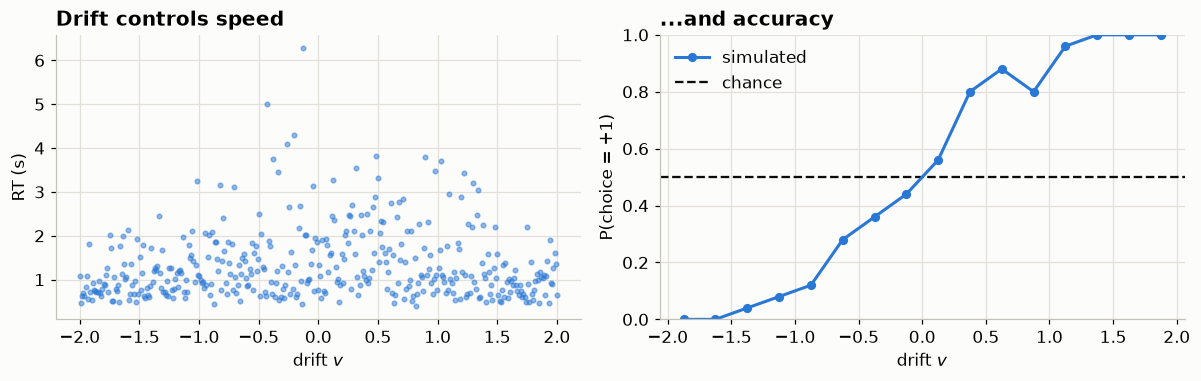

In [3]:
# Trial-varying drift: 400 trials, drift ramps from hard-negative to hard-positive.
v_by_trial = np.linspace(-2.0, 2.0, 400)
theta_matrix = np.column_stack([
    v_by_trial,
    np.full(400, 1.2),   # a
    np.full(400, 0.5),   # z
    np.full(400, 0.3),   # t
])

trialwise = simulator(theta=theta_matrix, model="ddm", n_samples=1,
                      random_state=RANDOM_SEED)
rt = trialwise["rts"].flatten()
ch = trialwise["choices"].flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(v_by_trial, rt, "o", color=S.PRIMARY, ms=3, alpha=0.5, ls="none")
ax1.set(title="Drift controls speed", xlabel="drift $v$", ylabel="RT (s)")

# Choice proportion in drift bins
bins = np.linspace(-2, 2, 17)
idx = np.digitize(v_by_trial, bins) - 1
prop = [np.mean(ch[idx == i] == 1) if (idx == i).sum() else np.nan
        for i in range(len(bins) - 1)]
ax2.plot(0.5 * (bins[:-1] + bins[1:]), prop, "o-", color=S.PRIMARY, label="simulated")
S.truth_line(ax2, 0.5, label="chance")
ax2.set(title="...and accuracy", xlabel="drift $v$", ylabel="P(choice = +1)", ylim=(0, 1))
ax2.legend()
fig.tight_layout()

> **Poll.** Drift `v` is negative on a trial. Which is true?
>
> **A.** The trial is faster and more likely to end at `+1`.
> **B.** The trial is slower and more likely to end at `-1`.
> **C.** The trial is equally fast either way; only accuracy changes.
> **D.** The trial drifts toward `-1`, and is *faster* the more negative `v` is.

<details>
<summary>Answer</summary>

**D.** The sign of `v` picks the boundary; the *magnitude* sets how fast
evidence accumulates. Strongly negative drift is both fast and reliably `-1`.
The slowest trials are the ones with drift near zero — visible as the tall
spike in the middle of the left panel. Speed and accuracy are governed by the
same quantity here, which is exactly why they trade off.

</details>

## 2. The model zoo, by introspection

There are **113** models registered. Do not memorise them — interrogate them.
Every model carries its own parameter names and the box those parameters live
in.

In [4]:
print(f"{len(model_config.keys())} models registered\n")
for name in ["ddm", "angle", "weibull", "lba3"]:
    c = model_config[name]
    lo, hi = c["param_bounds"]
    box = ", ".join(f"{p} [{l:g}, {h:g}]" for p, l, h in zip(c["params"], lo, hi))
    print(f"{name:8s} choices={str(c['choices']):9s} {box}")

113 models registered

ddm      choices=[-1, 1]   v [-3, 3], a [0.3, 2.5], z [0.1, 0.9], t [0, 2]
angle    choices=[-1, 1]   v [-3, 3], a [0.3, 3], z [0.1, 0.9], t [0.001, 2], theta [-0.1, 1.3]
weibull  choices=[-1, 1]   v [-2.5, 2.5], a [0.3, 2.5], z [0.2, 0.8], t [0.001, 2], alpha [0.31, 4.99], beta [0.31, 6.99]
lba3     choices=[0, 1, 2] A [0, 1], b [0, 1], v0 [0, 1], v1 [0.1, 1.1], v2 [0.1, 0.5]


`angle` is the DDM plus one parameter, `theta`, which tilts the decision
boundary inward over time — evidence needed to commit *decreases* the longer
you deliberate. Look at what that does, both to the boundary and to the RT
distribution.

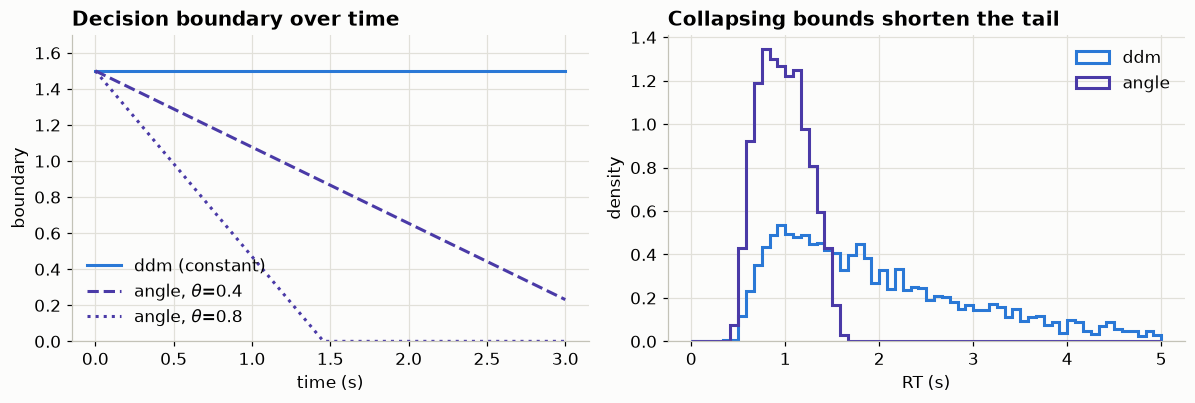

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: the boundary itself
t_grid = np.linspace(0, 3, 200)
a0 = 1.5
ax1.plot(t_grid, np.full_like(t_grid, a0), color=S.PRIMARY, label="ddm (constant)")
for theta_val, ls in [(0.4, "--"), (0.8, ":")]:
    ax1.plot(t_grid, np.maximum(a0 - np.tan(theta_val) * t_grid, 0),
             color=S.NAIVE, linestyle=ls, label=f"angle, $\\theta$={theta_val}")
ax1.set(title="Decision boundary over time", xlabel="time (s)",
        ylabel="boundary", ylim=(0, 1.7))
ax1.legend()

# Right: what that does to RTs
for name, theta, colour in [("ddm", [0.5, 1.5, 0.5, 0.3], S.PRIMARY),
                            ("angle", [0.5, 1.5, 0.5, 0.3, 0.8], S.NAIVE)]:
    o = simulator(theta=theta, model=name, n_samples=3000, random_state=RANDOM_SEED)
    ax2.hist(o["rts"].flatten(), bins=60, range=(0, 5), density=True,
             histtype="step", lw=2, color=colour, label=name)
ax2.set(title="Collapsing bounds shorten the tail", xlabel="RT (s)", ylabel="density")
ax2.legend()
fig.tight_layout()

That is the whole game: a parameter with a mechanistic meaning produces a
specific, *visible* signature in the data. Model building is choosing which
signatures you want to be able to express.

### Exercise 1

Pick any model from the zoo that we have not plotted, print its parameters and
bounds, simulate 2000 trials at a parameter setting of your choice, and plot
the RT distribution split by choice.

<details>
<summary>One solution</summary>

```python
name = "weibull"
c = model_config[name]
print(c["params"], c["param_bounds"])

# v, a, z, t, alpha, beta  — alpha/beta shape the collapsing boundary
o = simulator(theta=[0.6, 1.4, 0.5, 0.3, 2.0, 2.5], model=name,
              n_samples=2000, random_state=0)
rt, ch = o["rts"].flatten(), o["choices"].flatten()

fig, ax = plt.subplots(figsize=(6, 3.5))
for c_val, colour, lbl in [(1, S.PRIMARY, "+1"), (-1, S.NAIVE, "-1")]:
    ax.hist(rt[ch == c_val], bins=50, range=(0, 4), density=True,
            histtype="step", lw=2, color=colour, label=f"choice {lbl}")
ax.set(xlabel="RT (s)", ylabel="density", title=f"{name}: RT by choice")
ax.legend()
```

</details>

## 3. Capstone — build your own model

Two routes, depending on how far you want to go. Both are ~15 lines.

### Route A — keep the diffusion machinery, change the boundary

Register a boundary function and graft it onto the DDM. The function takes
time `t` plus its own parameters and returns the **final boundary value**,
`a` included — it is not an offset that `a` gets added to. `a` must be listed
first in its parameter list.

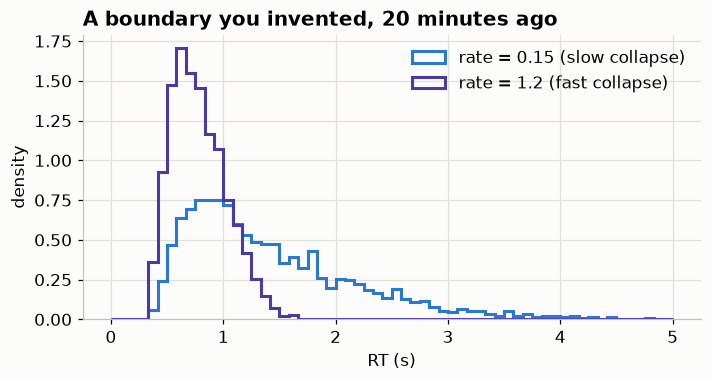

In [6]:
from ssms.config import register_boundary
from ssms.config.model_config_builder import ModelConfigBuilder
from ssms.basic_simulators.simulator_class import Simulator


def exp_collapse(t, a=1.0, rate=0.5):
    """Exponentially collapsing boundary: a * exp(-rate * t)."""
    import numpy as np          # import locally — the function gets pickled
    return a * np.exp(-rate * np.asarray(t))


register_boundary("exp_collapse", exp_collapse, ["a", "rate"])

cfg = ModelConfigBuilder.from_model("ddm")
cfg = ModelConfigBuilder.add_boundary(cfg, "exp_collapse", ["a", "rate"])

my_sim = Simulator(model=cfg)
o_slow = my_sim.simulate(theta={"v": 0.8, "a": 1.5, "z": 0.5, "t": 0.2, "rate": 0.15},
                         n_samples=3000, random_state=RANDOM_SEED)
o_fast = my_sim.simulate(theta={"v": 0.8, "a": 1.5, "z": 0.5, "t": 0.2, "rate": 1.2},
                         n_samples=3000, random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for o, colour, lbl in [(o_slow, S.PRIMARY, "rate = 0.15 (slow collapse)"),
                       (o_fast, S.NAIVE, "rate = 1.2 (fast collapse)")]:
    ax.hist(o["rts"].flatten(), bins=60, range=(0, 5), density=True,
            histtype="step", lw=2, color=colour, label=lbl)
ax.set(title="A boundary you invented, 20 minutes ago", xlabel="RT (s)", ylabel="density")
ax.legend()
fig.tight_layout()

::: {.callout-important}
## Two things that will bite you

**Registration is per-process.** `register_boundary` writes into an in-memory
registry. Restart the kernel and your model is gone — re-run the cell. In a
script, register at import time.

**`add_boundary` does not declare your new parameter.** Print `cfg["params"]`:
it is still `['v', 'a', 'z', 't']`. `rate` lives in `boundary_params` and is
accepted by `simulate`, but it is absent from `params`, `param_bounds`, and
`n_params`. Simulation works; anything that reads the parameter box — bounds,
priors, LAN training ranges — will not see `rate` until you add it yourself.
:::

In [7]:
print("params        :", cfg["params"])
print("boundary_name :", cfg["boundary_name"])
print("boundary_params:", cfg["boundary_params"])

params        : ['v', 'a', 'z', 't']
boundary_name : exp_collapse
boundary_params: ['a', 'rate']


### Route B — write the whole simulator

If your model is not a diffusion at all, hand over a function. It must accept
the parameters you declare, plus `n_samples`, and return a dict with `rts`,
`choices`, and `metadata`.

::: {.callout-warning}
## The documented example does not run
The `Simulator` docstring shows a custom function returning **1-D** arrays.
`simulate()` then calls `np.squeeze(rts, axis=1)` and raises
`AxisError: axis 1 is out of bounds`. **Return `(n_samples, 1)` arrays.** You
get 1-D back after the squeeze — return 2-D, receive 1-D. Also accept
`max_t`, `delta_t` and `random_state` or you will get a warning per call.
:::

P(choice = +1) = 0.663   (expected v1/(v0+v1) = 0.667)


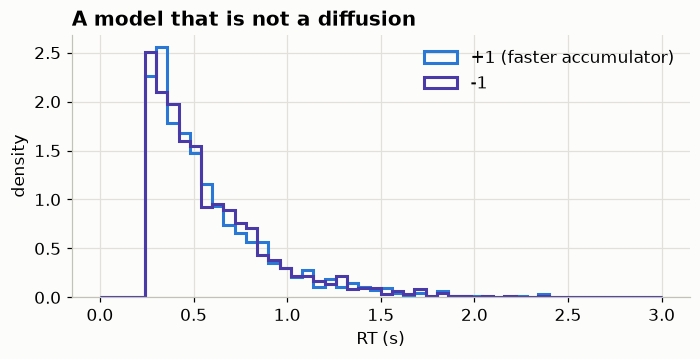

In [8]:
def racing_exponentials(v0, v1, t, n_samples=1000, max_t=20.0, delta_t=0.001,
                        random_state=None, **kwargs):
    """Two exponential accumulators race; first to finish picks the choice.

    Not a diffusion at all — just to show the interface is genuinely open.
    """
    import numpy as np
    rng = np.random.default_rng(random_state)
    f0 = rng.exponential(1.0 / v0, n_samples)
    f1 = rng.exponential(1.0 / v1, n_samples)
    rts = (np.minimum(f0, f1) + t).reshape(-1, 1)
    choices = np.where(f1 < f0, 1, -1).reshape(-1, 1)
    return {"rts": rts, "choices": choices,
            "metadata": {"model": "racing_exponentials", "n_samples": n_samples}}


race = Simulator(simulator_function=racing_exponentials,
                 params=["v0", "v1", "t"], nchoices=2)
o = race.simulate(theta={"v0": 1.0, "v1": 2.0, "t": 0.25},
                  n_samples=3000, random_state=RANDOM_SEED)

rt, ch = np.asarray(o["rts"]).flatten(), np.asarray(o["choices"]).flatten()
print(f"P(choice = +1) = {(ch == 1).mean():.3f}   (expected v1/(v0+v1) = {2/3:.3f})")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
for c_val, colour, lbl in [(1, S.PRIMARY, "+1 (faster accumulator)"),
                           (-1, S.NAIVE, "-1")]:
    ax.hist(rt[ch == c_val], bins=50, range=(0, 3), density=True,
            histtype="step", lw=2, color=colour, label=lbl)
ax.set(title="A model that is not a diffusion", xlabel="RT (s)", ylabel="density")
ax.legend()
fig.tight_layout()

The analytic check matters: for two racing exponentials,
$P(\text{choice}=+1) = v_1/(v_0+v_1)$. We recovered it. **Always find one
quantity your simulator must reproduce in closed form** — it is the cheapest
bug detector you will ever write.

### Exercise 2

Modify `racing_exponentials` so the two accumulators share a common
*non-decision* time but have **separate** start delays. Simulate, and check
whether `P(choice = +1)` still matches the closed form.

<details>
<summary>One solution, and the point of it</summary>

```python
def racing_with_delays(v0, v1, t, d0=0.0, d1=0.0, n_samples=1000,
                       max_t=20.0, delta_t=0.001, random_state=None, **kw):
    import numpy as np
    rng = np.random.default_rng(random_state)
    f0 = rng.exponential(1.0 / v0, n_samples) + d0
    f1 = rng.exponential(1.0 / v1, n_samples) + d1
    rts = (np.minimum(f0, f1) + t).reshape(-1, 1)
    choices = np.where(f1 < f0, 1, -1).reshape(-1, 1)
    return {"rts": rts, "choices": choices,
            "metadata": {"model": "racing_with_delays", "n_samples": n_samples}}
```

It does **not** match any more: a head start is worth the same as a rate
advantage, so `d0`/`d1` and `v0`/`v1` push accuracy in the same direction.
You have just built a model with a parameter trade-off — two different
parameter settings producing near-identical data. Hold that thought; the next
session is about what that does to inference.

</details>

## 4. The dataset for the next session

We hand two datasets forward. Same model, same number of trials — the only
difference is the drift, and therefore the error rate.

In [9]:
import pandas as pd

def make_dataset(v, label, n=800, seed=RANDOM_SEED):
    o = simulator(theta=[v, 1.2, 0.5, 0.3], model="ddm", n_samples=n, random_state=seed)
    return pd.DataFrame({"rt": o["rts"].flatten(),
                         "response": o["choices"].flatten().astype(int),
                         "design": label})

# v = 0.5 lands ~23% errors, inside the 15-35% band that Lüken et al. (2025)
# recommend for identifiability. v = 3.0 is the pathological case: ~0% errors.
balanced = make_dataset(0.5, "balanced")
extreme = make_dataset(3.0, "extreme")

for df in (balanced, extreme):
    err = (df["response"] == -1).mean()
    print(f"{df['design'][0]:9s} error rate {err:6.1%}   mean RT {df['rt'].mean():.3f}s")

outdir = pathlib.Path("data")
outdir.mkdir(exist_ok=True)
pd.concat([balanced, extreme]).to_csv(outdir / "ddm_two_designs.csv", index=False)
print(f"\nwrote {outdir / 'ddm_two_designs.csv'}")

balanced  error rate  22.9%   mean RT 1.579s
extreme   error rate   0.0%   mean RT 0.705s

wrote data/ddm_two_designs.csv


::: {.callout-note}
## Where this is going
Both datasets come from the *same model* with the *same* `a`, `z`, `t`. Only
the drift differs. One of them supports clean parameter recovery and the other
does not — and it is not the one most people would guess. That is the next
session.
:::

`data/` is gitignored: it is regenerated by running this notebook, never
committed.

## What to take away

- The simulator is the model. If you cannot generate from it, you do not
  understand it yet.
- **Interrogate, do not memorise**: `model_config[name]["params"]` and
  `["param_bounds"]` tell you what any of the 113 models wants.
- Choices are `[-1, +1]`; `rts` is 2-D; the docstring lies about the key name.
- You can add a boundary in ~5 lines, or replace the simulator entirely in
  ~15. Registration is per-process, and `add_boundary` will not declare your
  parameter for you.
- Always find one closed-form quantity your simulator must reproduce.